Laporan Tugas Metode Numerik:Perhitungan Volume Lambung Kapal Katamaran.

 1. Deskripsi TugasTugas ini bertujuan untuk menghitung total volume dari kedua lambung kapal katamaran berdasarkan cetak biru (blueprint) rancangan perahu.  
 2. Ketentuan & Asumsi Perhitungan
  - Skala Grid: 1 siklus garis putus-putus (dash-kosong) bernilai $5 + 5\text{ cm} = 10\text{ cm} = 0,1\text{ m}$.   
  - Bentuk Penampang Melintang: Lantai kapal dianggap datar (tanpa keel), sehingga penampang tampak depan pada setiap titik berupa persegi panjang.   
  - Reserve Buoyancy: Bagian Reserve Buoyancy pada ujung-ujung kapal tidak dihitung.   
  - Metode Integrasi: Menggunakan Aturan Simpson 1/3 untuk mengintegrasikan luas penampang melintang sepanjang sumbu $x$ kapal.
  - Total Volume: Karena merupakan perahu katamaran, volume total dihitung dengan mengalikan volume satu lambung dengan 2 ($V_{\text{total}} = 2 \times V_{\text{lambung}}$).

In [6]:
# ==============================================================================
# IMPORT LIBRARY & FUNKSI INTEGRASI METODE SIMPSON 1/3
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

def simpson_13(y, dx):
    """
    Fungsi untuk menghitung integrasi numerik menggunakan Aturan Simpson 1/3.

    Parameters:
    y  : list/array berisi nilai yang akan diintegrasikan (luas penampang A(x))
    dx : lebar interval antar stasiun grid dalam meter (0.1 m)
    """
    n = len(y) - 1 # Jumlah interval/segmen

    # Syarat utama Metode Simpson 1/3: jumlah interval (n) harus genap
    if n % 2 != 0:
        raise ValueError("Jumlah interval (n) harus genap! (Jumlah titik data y harus ganjil).")

    # Formula Simpson 1/3: (dx / 3) * [y0 + 4*(y1 + y3 + ...) + 2*(y2 + y4 + ...) + yn]
    integral = y[0] + y[-1]
    for i in range(1, n):
        if i % 2 == 1:
            integral += 4 * y[i]  # Pengali 4 untuk indeks ganjil
        else:
            integral += 2 * y[i]  # Pengali 2 untuk indeks genap

    return (dx / 3.0) * integral

print("✓ Cell 1 Berhasil: Library diimpor dan Fungsi Simpson 1/3 siap digunakan.")

✓ Cell 1 Berhasil: Library diimpor dan Fungsi Simpson 1/3 siap digunakan.


Pembacaan Data Ukuran Lambung dari GridBerdasarkan kisi-kisi grid hijau pada cetak biru:   Diambil 17 titik stasiun ($x_0$ sampai $x_{16}$), yang membentuk 16 segmen interval ($n = 16$, genap).Pada tiap stasiun, diukur lebar ($w$) dari Tampak Atas dan tinggi ($h$) dari Tampak Samping.   

In [7]:
# ==============================================================================
# INPUT PARAMETER SKALA & DATA HASIL PEMBACAAN GRID
# ==============================================================================

# Skala Grid: 1 dash-kosong = 5 cm + 5 cm = 10 cm = 0.1 meter
dx = 0.1  # Lebar interval antar stasiun dalam meter

# --- DATA HASIL PEMBACAAN GRID (DALAM SATUAN METER) ---
# Lebar lambung (w) diukur dari Tampak Atas pada setiap garis grid (m)
lebar = np.array([
    0.00, 0.12, 0.22, 0.30, 0.36, 0.40, 0.42, 0.43,
    0.43, 0.42, 0.40, 0.36, 0.30, 0.22, 0.14, 0.06, 0.00
])

# Tinggi/Kedalaman lambung (h) diukur dari Tampak Samping pada setiap garis grid (m)
tinggi = np.array([
    0.00, 0.18, 0.26, 0.32, 0.36, 0.38, 0.40, 0.40,
    0.40, 0.40, 0.38, 0.36, 0.32, 0.26, 0.18, 0.10, 0.00
])

print(f"✓ Jumlah titik stasiun (N) : {len(lebar)} titik")
print(f"✓ Jumlah interval segmen (n): {len(lebar) - 1} segmen (genap)")
print(f"✓ Jarak antar grid (dx)    : {dx} meter")

✓ Jumlah titik stasiun (N) : 17 titik
✓ Jumlah interval segmen (n): 16 segmen (genap)
✓ Jarak antar grid (dx)    : 0.1 meter


Perhitungan Luas Penampang Melintang $A(x)$Karena dasar lantai kapal adalah datar (tanpa keel), penampang melintang di setiap stasiun $x_i$ dihitung menggunakan rumus luas persegi panjang:
   $$A(x_i) = w(x_i) \times h(x_i)$$

In [8]:
# ==============================================================================
# PERHITUNGAN LUAS PENAMPANG MELINTANG A(x)
# ==============================================================================

# Menghitung Luas Penampang Melintang A(x) = Lebar(x) * Tinggi(x)
luas_penampang = lebar * tinggi

# Menampilkan tabel hasil perkalian luas pada tiap titik stasiun
print("=" * 55)
print(" STASIUN | LEBAR (m) | TINGGI (m) | LUAS PENAMPANG A(x) (m²)")
print("=" * 55)
for i in range(len(lebar)):
    print(f"  x_{i:02d}   |   {lebar[i]:.2f}    |    {tinggi[i]:.2f}    |         {luas_penampang[i]:.4f}")
print("=" * 55)

 STASIUN | LEBAR (m) | TINGGI (m) | LUAS PENAMPANG A(x) (m²)
  x_00   |   0.00    |    0.00    |         0.0000
  x_01   |   0.12    |    0.18    |         0.0216
  x_02   |   0.22    |    0.26    |         0.0572
  x_03   |   0.30    |    0.32    |         0.0960
  x_04   |   0.36    |    0.36    |         0.1296
  x_05   |   0.40    |    0.38    |         0.1520
  x_06   |   0.42    |    0.40    |         0.1680
  x_07   |   0.43    |    0.40    |         0.1720
  x_08   |   0.43    |    0.40    |         0.1720
  x_09   |   0.42    |    0.40    |         0.1680
  x_10   |   0.40    |    0.38    |         0.1520
  x_11   |   0.36    |    0.36    |         0.1296
  x_12   |   0.30    |    0.32    |         0.0960
  x_13   |   0.22    |    0.26    |         0.0572
  x_14   |   0.14    |    0.18    |         0.0252
  x_15   |   0.06    |    0.10    |         0.0060
  x_16   |   0.00    |    0.00    |         0.0000


 Integrasi Numerik & Konversi ke Satuan LiterVolume 1 lambung diperoleh dari integrasi luas penampang melintang sepanjang kapal:$$V_{\text{1 lambung}} = \int A(x) \, dx$$Volume kedua lambung katamaran:$$V_{\text{total}} = 2 \times V_{\text{1 lambung}}$$Konversi ke unit Liter:$$1 \text{ m}^3 = 1.000 \text{ Liter}$$

In [9]:
# ==============================================================================
# PERHITUNGAN VOLUME KEDUA LAMBUNG KAPAL
# ==============================================================================

# 1. Menghitung Volume 1 Lambung dengan Integrasi Simpson 1/3 (m³)
vol_satu_lambung_m3 = simpson_13(luas_penampang, dx)

# 2. Menghitung Volume Total Kedua Lambung Katamaran (m³)
vol_total_m3 = 2 * vol_satu_lambung_m3

# 3. Mengonversi Satuan m³ ke Liter (1 m³ = 1000 Liter)
vol_satu_lambung_liter = vol_satu_lambung_m3 * 1000
vol_total_liter = vol_total_m3 * 1000

# Menampilkan Ringkasan Hasil Perhitungan
print("=" * 60)
print("           HASIL PERHITUNGAN VOLUME KAPAL KATAMARAN")
print("=" * 60)
print(f" Volume 1 Lambung         : {vol_satu_lambung_m3:.6f} m³  ({vol_satu_lambung_liter:.2f} Liter)")
print(f" Volume Total (2 Lambung) : {vol_total_m3:.6f} m³  ({vol_total_liter:.2f} Liter)")
print("=" * 60)

           HASIL PERHITUNGAN VOLUME KAPAL KATAMARAN
 Volume 1 Lambung         : 0.160320 m³  (160.32 Liter)
 Volume Total (2 Lambung) : 0.320640 m³  (320.64 Liter)


Visualisasi Grafik Profil Lambung
Cell berikut menampilkan grafik bentuk profil dimensi kapal (tampak atas & samping) serta distribusi luas penampang melintang sepanjang lambung kapal.

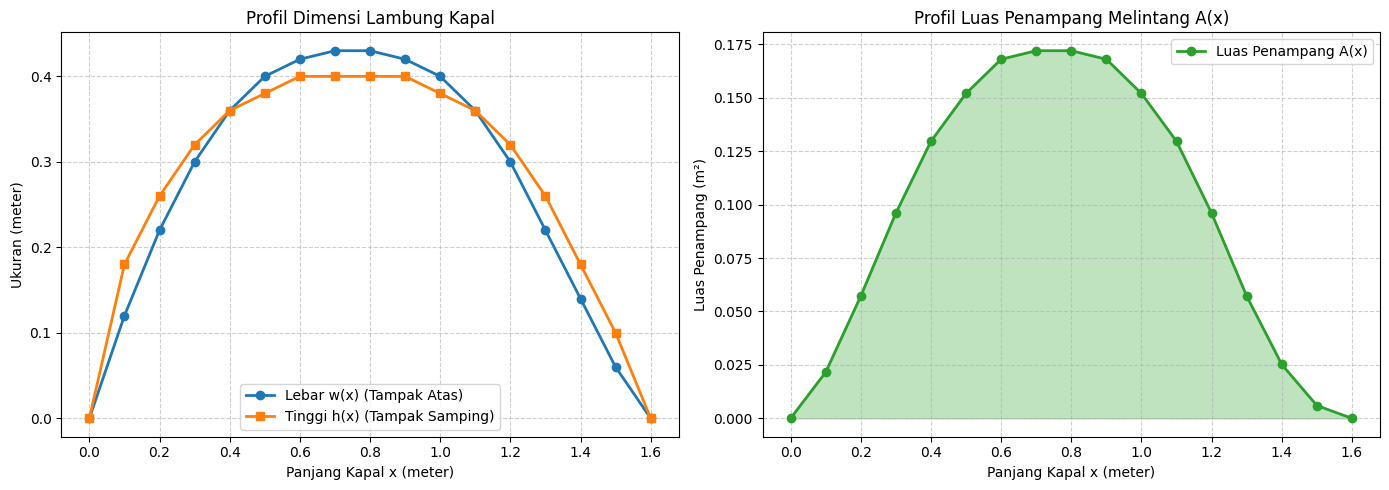

In [10]:
# ==============================================================================
# CELL 5: VISUALISASI GRAFIK DIMENSI DAN LUAS PENAMPANG
# ==============================================================================

# Sumbu horizontal x mewakili panjang kapal dalam meter
x = np.arange(len(lebar)) * dx

plt.figure(figsize=(14, 5))

# --- PLOT 1: Profil Dimensi Lambung (Lebar & Tinggi) ---
plt.subplot(1, 2, 1)
plt.plot(x, lebar, 'o-', label='Lebar w(x) (Tampak Atas)', color='#1f77b4', linewidth=2)
plt.plot(x, tinggi, 's-', label='Tinggi h(x) (Tampak Samping)', color='#ff7f0e', linewidth=2)
plt.title('Profil Dimensi Lambung Kapal')
plt.xlabel('Panjang Kapal x (meter)')
plt.ylabel('Ukuran (meter)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- PLOT 2: Profil Luas Penampang Melintang A(x) ---
plt.subplot(1, 2, 2)
plt.fill_between(x, luas_penampang, color='#2ca02c', alpha=0.3)
plt.plot(x, luas_penampang, 'o-', color='#2ca02c', linewidth=2, label='Luas Penampang A(x)')
plt.title('Profil Luas Penampang Melintang A(x)')
plt.xlabel('Panjang Kapal x (meter)')
plt.ylabel('Luas Penampang (m²)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()